<a href="https://colab.research.google.com/github/Tanishqnarayan/AIML/blob/main/AIML_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Dataset shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

CLASSIFICATION TARGET
Median target: 140.5

Class distribution:
class
0    221
1    221
Name: count, dtype: int64

Class meaning:
0 = Lower Progression
1 = Higher Progression

FEATURE INFORMATION
Number of features: 10
Number of samples: 442

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

TRAIN-TEST SPLIT
Training samples: 353
Testing samples: 89

Feature standardization completed.

BEST K VALUE
Best K: 7
Accuracy with best K: 80.9 %


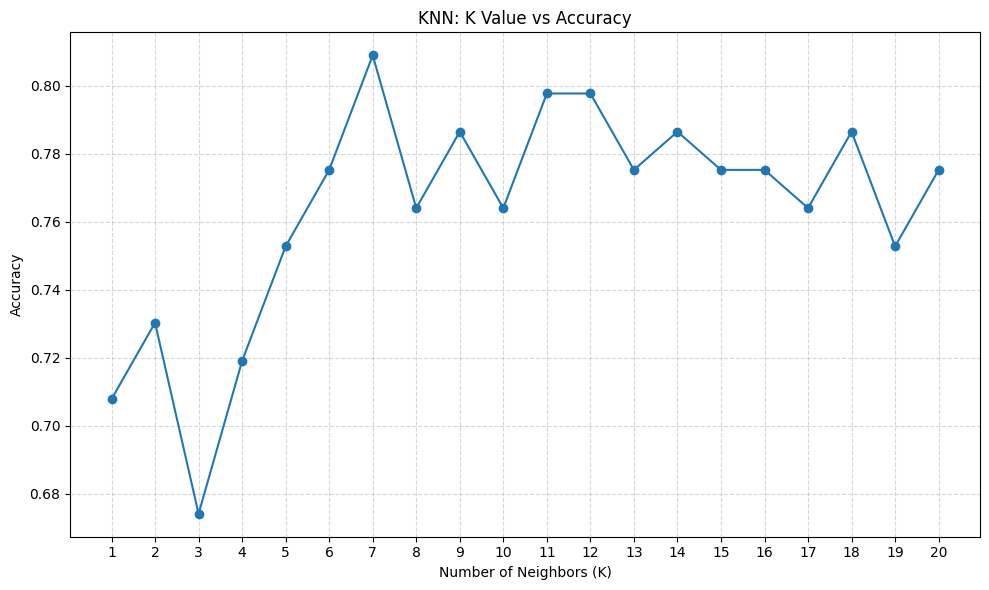


KNN MODEL
KNN model trained successfully.
Selected K: 7

Predictions generated successfully.

First 20 predictions:
[1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1]

MODEL PERFORMANCE
Accuracy  : 0.8090
Precision : 0.7872
Recall    : 0.8409
F1 Score  : 0.8132

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

 Lower Progression       0.83      0.78      0.80        45
Higher Progression       0.79      0.84      0.81        44

          accuracy                           0.81        89
         macro avg       0.81      0.81      0.81        89
      weighted avg       0.81      0.81      0.81        89


CONFUSION MATRIX
[[35 10]
 [ 7 37]]


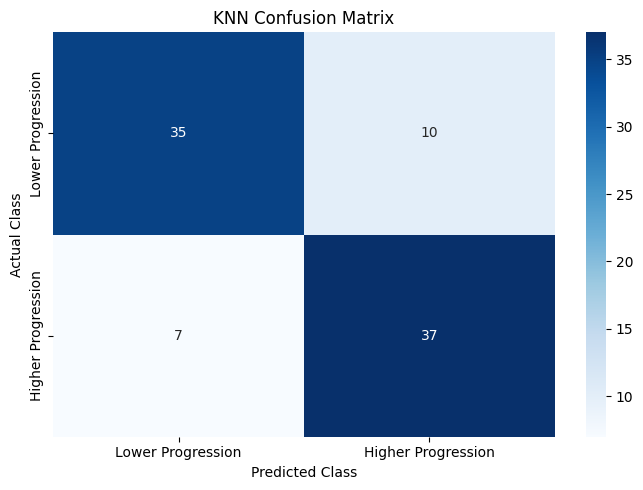

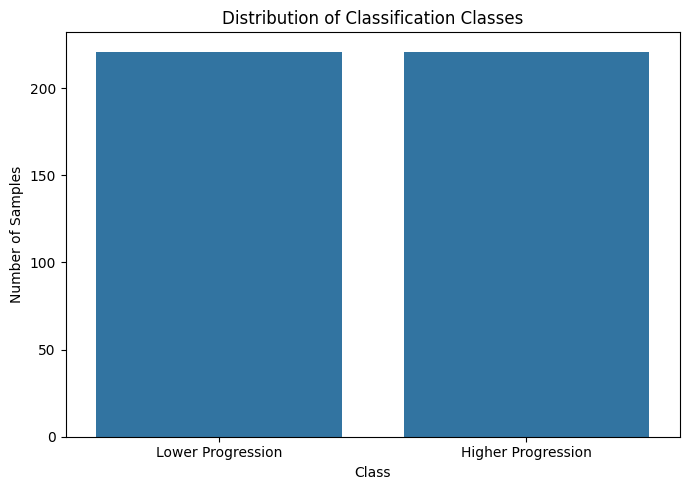


ACTUAL VS PREDICTED


,Actual,Predicted,Actual Label,Predicted Label
0,1,1,Higher,Higher
1,1,0,Higher,Lower
2,0,0,Lower,Lower
3,1,1,Higher,Higher
4,1,1,Higher,Higher
5,0,1,Lower,Higher
6,0,0,Lower,Lower
7,1,1,Higher,Higher
8,1,1,Higher,Higher
9,0,0,Lower,Lower


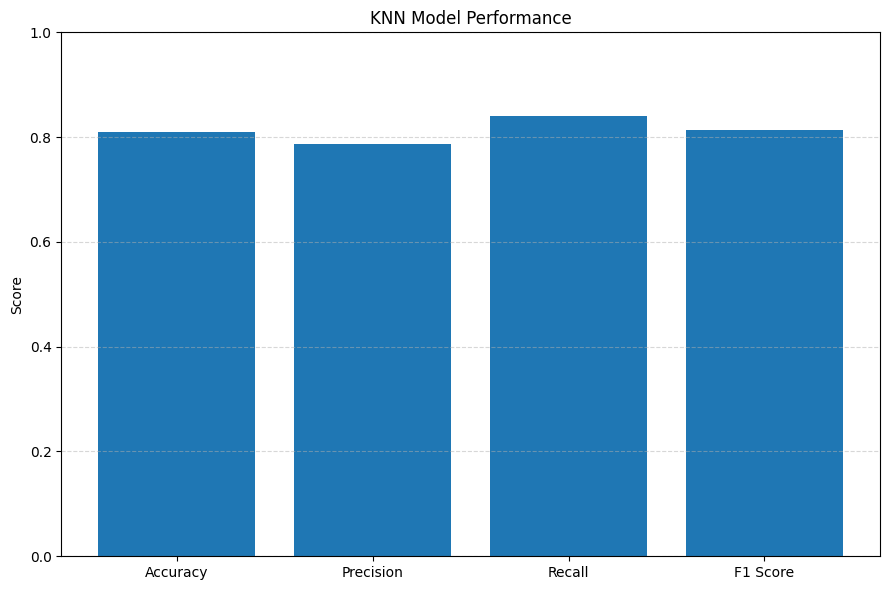


ASSIGNMENT 5 EXPORT COMPLETED
✓ 01_k_vs_accuracy.png
✓ 02_confusion_matrix.png
✓ 03_class_distribution.png
✓ 04_model_performance.png
✓ 05_results_and_observations.txt
✓ 06_KNN_Complete_Report.html
✓ classification_report.csv
✓ confusion_matrix.csv
✓ diabetes_classification_dataset.csv
✓ k_value_accuracy.csv
✓ model_metrics.csv
✓ predictions.csv

ZIP file created:
/content/Assignment_5_Complete_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# ASSIGNMENT 5
# K-NEAREST NEIGHBORS (KNN) CLASSIFICATION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from google.colab import files


# ============================================================
# 2. LOAD DIABETES DATASET
# ============================================================

data = load_diabetes(as_frame=True)

df = data.frame

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())


# ============================================================
# 3. CREATE BINARY CLASSIFICATION TARGET
# ============================================================

# Calculate median of target
median_target = df["target"].median()

# Create binary class
# 0 = Lower progression
# 1 = Higher progression

df["class"] = (
    df["target"] >= median_target
).astype(int)

print("\n" + "=" * 60)
print("CLASSIFICATION TARGET")
print("=" * 60)

print("Median target:", median_target)

print("\nClass distribution:")
print(df["class"].value_counts().sort_index())

print("\nClass meaning:")
print("0 = Lower Progression")
print("1 = Higher Progression")


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

# Remove original continuous target
# and new class column from X

X = df.drop(
    columns=["target", "class"]
)

y = df["class"]

print("\n" + "=" * 60)
print("FEATURE INFORMATION")
print("=" * 60)

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 6. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature standardization completed.")


# ============================================================
# 7. FIND BEST K VALUE
# ============================================================

k_values = range(1, 21)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    predictions = knn.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    accuracies.append(accuracy)


# Find K with highest accuracy
best_k = list(k_values)[
    np.argmax(accuracies)
]

best_accuracy = max(accuracies)

print("\n" + "=" * 60)
print("BEST K VALUE")
print("=" * 60)

print("Best K:", best_k)

print(
    "Accuracy with best K:",
    round(best_accuracy * 100, 2),
    "%"
)


# ============================================================
# 8. PLOT K VS ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(list(k_values))

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. TRAIN FINAL KNN MODEL
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("\n" + "=" * 60)
print("KNN MODEL")
print("=" * 60)

print(
    "KNN model trained successfully."
)

print("Selected K:", best_k)


# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

y_pred = knn_model.predict(
    X_test_scaled
)

print("\nPredictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])


# ============================================================
# 11. CALCULATE PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Lower Progression",
        "Higher Progression"
    ]
)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(report)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# ============================================================
# 14. CONFUSION MATRIX GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Progression",
        "Higher Progression"
    ],
    yticklabels=[
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.title(
    "KNN Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. CLASS DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.xticks(
    [0, 1],
    [
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.title(
    "Distribution of Classification Classes"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Actual Label"] = (
    comparison["Actual"]
    .map({
        0: "Lower",
        1: "Higher"
    })
)

comparison["Predicted Label"] = (
    comparison["Predicted"]
    .map({
        0: "Lower",
        1: "Higher"
    })
)

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED")
print("=" * 60)

display(
    comparison.head(20)
)


# ============================================================
# 17. PERFORMANCE COMPARISON GRAPH
# ============================================================

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(9, 6))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title(
    "KNN Model Performance"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. CREATE EXPORT FOLDER
# ============================================================

folder = "Assignment_5_Complete_Results"

if os.path.exists(folder):

    shutil.rmtree(folder)

os.makedirs(folder)


# ============================================================
# 19. SAVE DATASET
# ============================================================

df.to_csv(
    f"{folder}/diabetes_classification_dataset.csv",
    index=False
)


# ============================================================
# 20. SAVE PREDICTIONS
# ============================================================

prediction_results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

prediction_results.to_csv(
    f"{folder}/predictions.csv",
    index=False
)


# ============================================================
# 21. SAVE K VALUES AND ACCURACIES
# ============================================================

k_results = pd.DataFrame({

    "K": list(k_values),

    "Accuracy": accuracies

})

k_results.to_csv(
    f"{folder}/k_value_accuracy.csv",
    index=False
)


# ============================================================
# 22. SAVE CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Lower Progression",
        "Higher Progression"
    ],
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    f"{folder}/classification_report.csv"
)


# ============================================================
# 23. SAVE CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,

    index=[
        "Actual Lower",
        "Actual Higher"
    ],

    columns=[
        "Predicted Lower",
        "Predicted Higher"
    ]
)

cm_df.to_csv(
    f"{folder}/confusion_matrix.csv"
)


# ============================================================
# 24. SAVE METRICS
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Best K"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        best_k
    ]

})

metrics_df.to_csv(
    f"{folder}/model_metrics.csv",
    index=False
)


# ============================================================
# 25. SAVE GRAPH 1 - K VS ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    accuracies,
    marker="o"
)

plt.xlabel(
    "Number of Neighbors (K)"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "KNN: K Value vs Accuracy"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{folder}/01_k_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 26. SAVE GRAPH 2 - CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Progression",
        "Higher Progression"
    ],
    yticklabels=[
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "KNN Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    f"{folder}/02_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 27. SAVE GRAPH 3 - CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.xticks(
    [0, 1],
    [
        "Lower Progression",
        "Higher Progression"
    ]
)

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.title(
    "Distribution of Classification Classes"
)

plt.tight_layout()

plt.savefig(
    f"{folder}/03_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 28. SAVE GRAPH 4 - PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title(
    "KNN Model Performance"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{folder}/04_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 29. CREATE OBSERVATIONS FILE
# ============================================================

observations = f"""
============================================================
ASSIGNMENT 5
K-NEAREST NEIGHBORS (KNN) CLASSIFICATION
============================================================

Dataset:
Scikit-learn Diabetes Dataset

Number of samples:
{df.shape[0]}

Number of independent features:
{X.shape[1]}

Classification Algorithm:
K-Nearest Neighbors (KNN)

Training samples:
{X_train.shape[0]}

Testing samples:
{X_test.shape[0]}

Median target used:
{median_target:.4f}

Best K:
{best_k}

============================================================
MODEL PERFORMANCE
============================================================

Accuracy:
{accuracy:.4f}

Accuracy (%):
{accuracy * 100:.2f}%

Precision:
{precision:.4f}

Recall:
{recall:.4f}

F1 Score:
{f1:.4f}

============================================================
OBSERVATIONS
============================================================

1. The continuous Diabetes target was converted into
   two classes using the median target value.

2. The 10 independent features were used for classification.

3. The dataset was divided into training and testing sets
   using an 80:20 ratio.

4. The features were standardized before applying KNN
   because KNN is based on distance calculations.

5. Different K values from 1 to 20 were evaluated.

6. The K value producing the highest test accuracy was
   selected as the final K.

7. The final KNN model was evaluated using accuracy,
   precision, recall and F1-score.

8. A confusion matrix was generated to visualize the
   correct and incorrect predictions.

============================================================
CONCLUSION
============================================================

The K-Nearest Neighbors classification algorithm was
successfully implemented on the Diabetes dataset.

The input features were standardized and different values
of K were tested to identify a suitable number of neighbors.
The final model was evaluated using several classification
metrics and a confusion matrix.

============================================================
"""

with open(
    f"{folder}/05_results_and_observations.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(observations)


# ============================================================
# 30. CREATE HTML REPORT
# ============================================================

html = f"""
<html>

<head>

<title>Assignment 5 - KNN Results</title>

<style>

body {{
    font-family: Arial;
    margin: 40px;
}}

h1, h2 {{
    color: #333;
}}

img {{
    width: 750px;
    max-width: 100%;
    margin-bottom: 30px;
}}

table {{
    border-collapse: collapse;
    width: 100%;
}}

th, td {{
    border: 1px solid #999;
    padding: 8px;
    text-align: center;
}}

th {{
    background-color: #eee;
}}

</style>

</head>

<body>

<h1>
Assignment 5: K-Nearest Neighbors Classification
</h1>

<h2>Dataset Information</h2>

<p>
Dataset: Scikit-learn Diabetes Dataset
</p>

<p>
Samples: {df.shape[0]}
</p>

<p>
Independent Features: {X.shape[1]}
</p>

<p>
Algorithm: K-Nearest Neighbors
</p>

<p>
Training Samples: {X_train.shape[0]}
</p>

<p>
Testing Samples: {X_test.shape[0]}
</p>

<h2>Best K</h2>

<p>
Best K:
<b>{best_k}</b>
</p>

<h2>Performance</h2>

<p>
Accuracy:
<b>{accuracy * 100:.2f}%</b>
</p>

<p>
Precision:
<b>{precision:.4f}</b>
</p>

<p>
Recall:
<b>{recall:.4f}</b>
</p>

<p>
F1 Score:
<b>{f1:.4f}</b>
</p>

<h2>K Value vs Accuracy</h2>

<img src="01_k_vs_accuracy.png">

<h2>Confusion Matrix</h2>

<img src="02_confusion_matrix.png">

<h2>Class Distribution</h2>

<img src="03_class_distribution.png">

<h2>Model Performance</h2>

<img src="04_model_performance.png">

<h2>Classification Report</h2>

{report_df.to_html()}

<h2>Conclusion</h2>

<p>
The K-Nearest Neighbors algorithm was successfully
implemented on the Diabetes dataset. The features were
standardized before training, and multiple K values were
tested. The final model was evaluated using accuracy,
precision, recall, F1-score and a confusion matrix.
</p>

</body>

</html>
"""

with open(
    f"{folder}/06_KNN_Complete_Report.html",
    "w",
    encoding="utf-8"
) as f:

    f.write(html)


# ============================================================
# 31. CREATE ZIP FILE
# ============================================================

zip_path = shutil.make_archive(
    "Assignment_5_Complete_Results",
    "zip",
    folder
)


# ============================================================
# 32. DISPLAY EXPORTED FILES
# ============================================================

print("\n" + "=" * 60)
print("ASSIGNMENT 5 EXPORT COMPLETED")
print("=" * 60)

for filename in sorted(
    os.listdir(folder)
):

    print("✓", filename)

print("\nZIP file created:")
print(zip_path)


# ============================================================
# 33. DOWNLOAD EVERYTHING
# ============================================================

files.download(zip_path)